# A Comparative Analysis of Machine Learning Models for Customer Churn Prediction in the Banking Industry
**Odegbami, Oluwagbemiro Olamide — 210805525**  
Department of Computer Sciences, University of Lagos

---

## 0. Imports & Setup

In [4]:
# ── Core ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# ── Preprocessing ─────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# ── Imbalance ─────────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Models ────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
tf.random.set_seed(42)

# ── Metrics ───────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

# ── Explainability ────────────────────────────────────────────────────────
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 1. Data Loading & Initial Inspection

In [5]:
df = pd.read_csv("Bank Customer Churn Prediction.csv")
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
print('=== Data Types & Non-Null Counts ===')
df.info()
print('\n=== Descriptive Statistics ===')
df.describe()

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB

=== Descriptive Statistics ===


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
print('=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Duplicate Rows ===')
print(df.duplicated().sum())

=== Missing Values ===
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

=== Duplicate Rows ===
0


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Class Distribution (Target Variable)

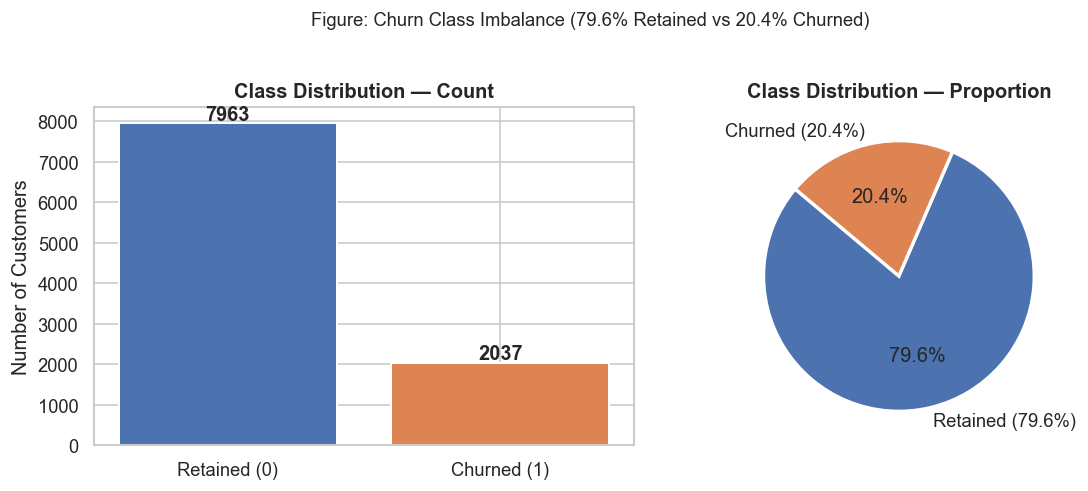

Retained: 7,963 (79.6%)
Churned : 2,037 (20.4%)


In [8]:
churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar
axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts,
            color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.2)
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 80, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution — Count', fontweight='bold')
axes[0].set_ylabel('Number of Customers')

# Pie
axes[1].pie(churn_pct, labels=['Retained (79.6%)', 'Churned (20.4%)'],
            colors=['#4C72B0', '#DD8452'], autopct='%1.1f%%',
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution — Proportion', fontweight='bold')

plt.suptitle('Figure: Churn Class Imbalance (79.6% Retained vs 20.4% Churned)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig_class_distribution.png', bbox_inches='tight')
plt.show()
print(f'Retained: {churn_counts[0]:,} ({churn_pct[0]:.1f}%)')
print(f'Churned : {churn_counts[1]:,} ({churn_pct[1]:.1f}%)')

### 2.2 Univariate Distributions — Numerical Features

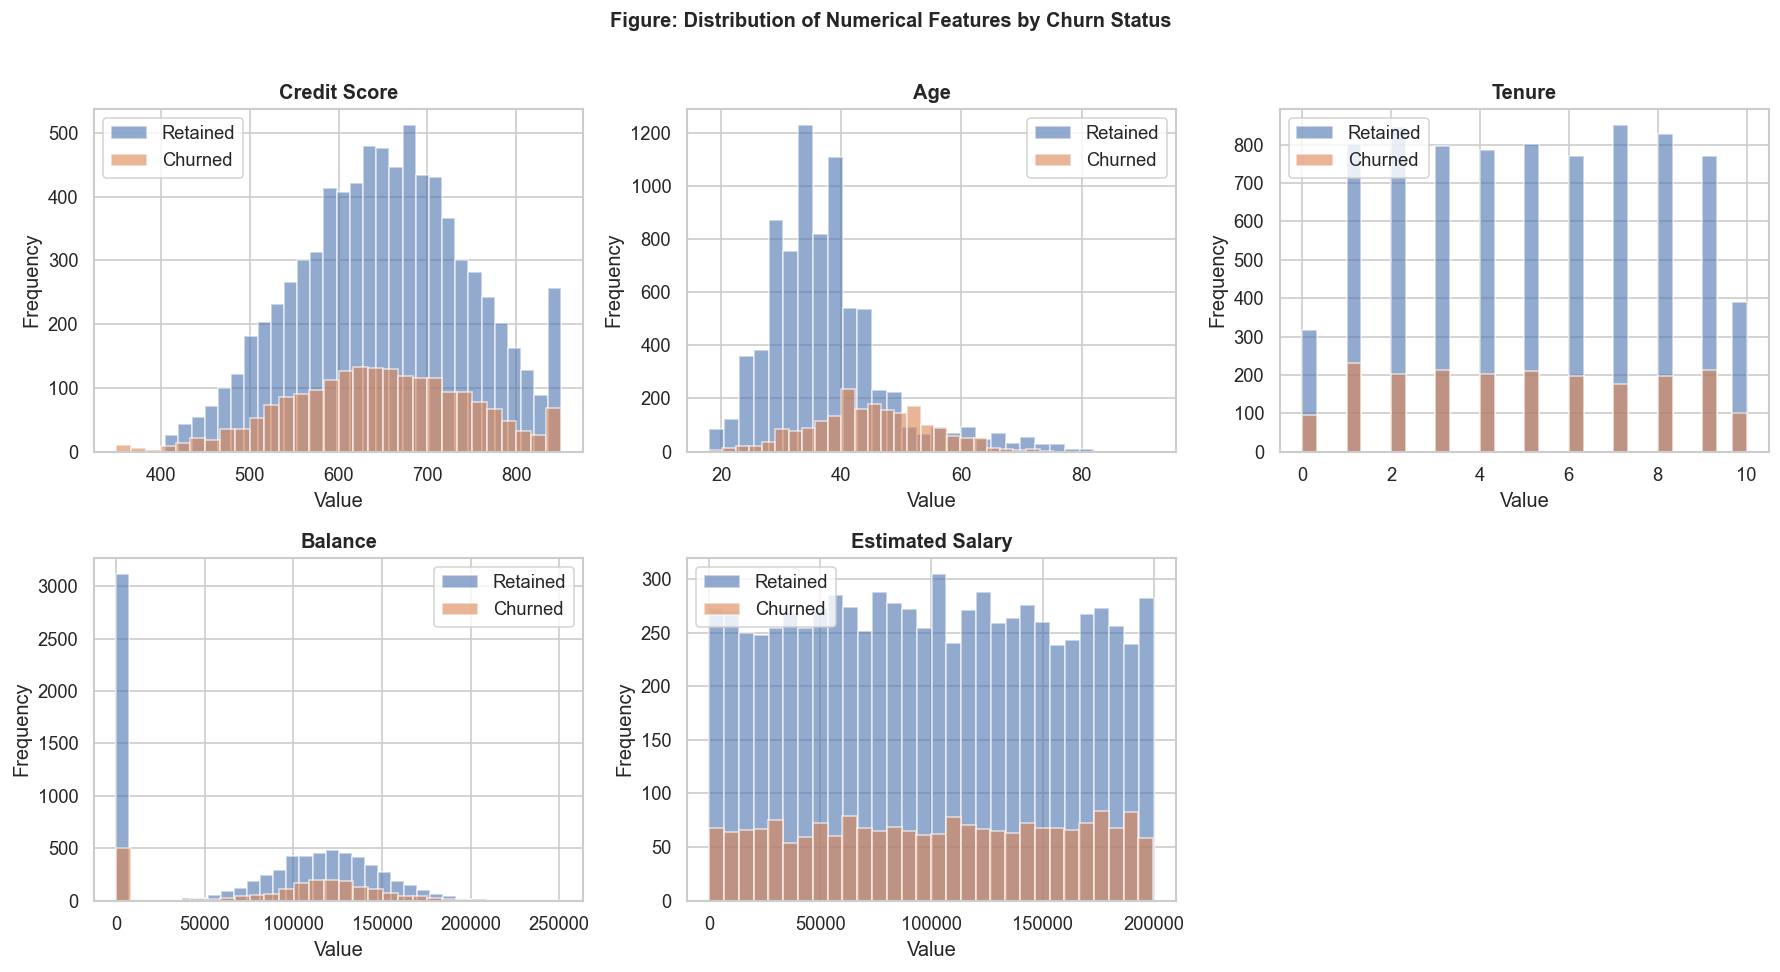

In [9]:
num_features = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
        subset = df[df['churn'] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color,
                     label=f'{"Retained" if label==0 else "Churned"}')
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

axes[5].axis('off')
plt.suptitle('Figure: Distribution of Numerical Features by Churn Status',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_numerical_distributions.png', bbox_inches='tight')
plt.show()

### 2.3 Categorical Feature Analysis

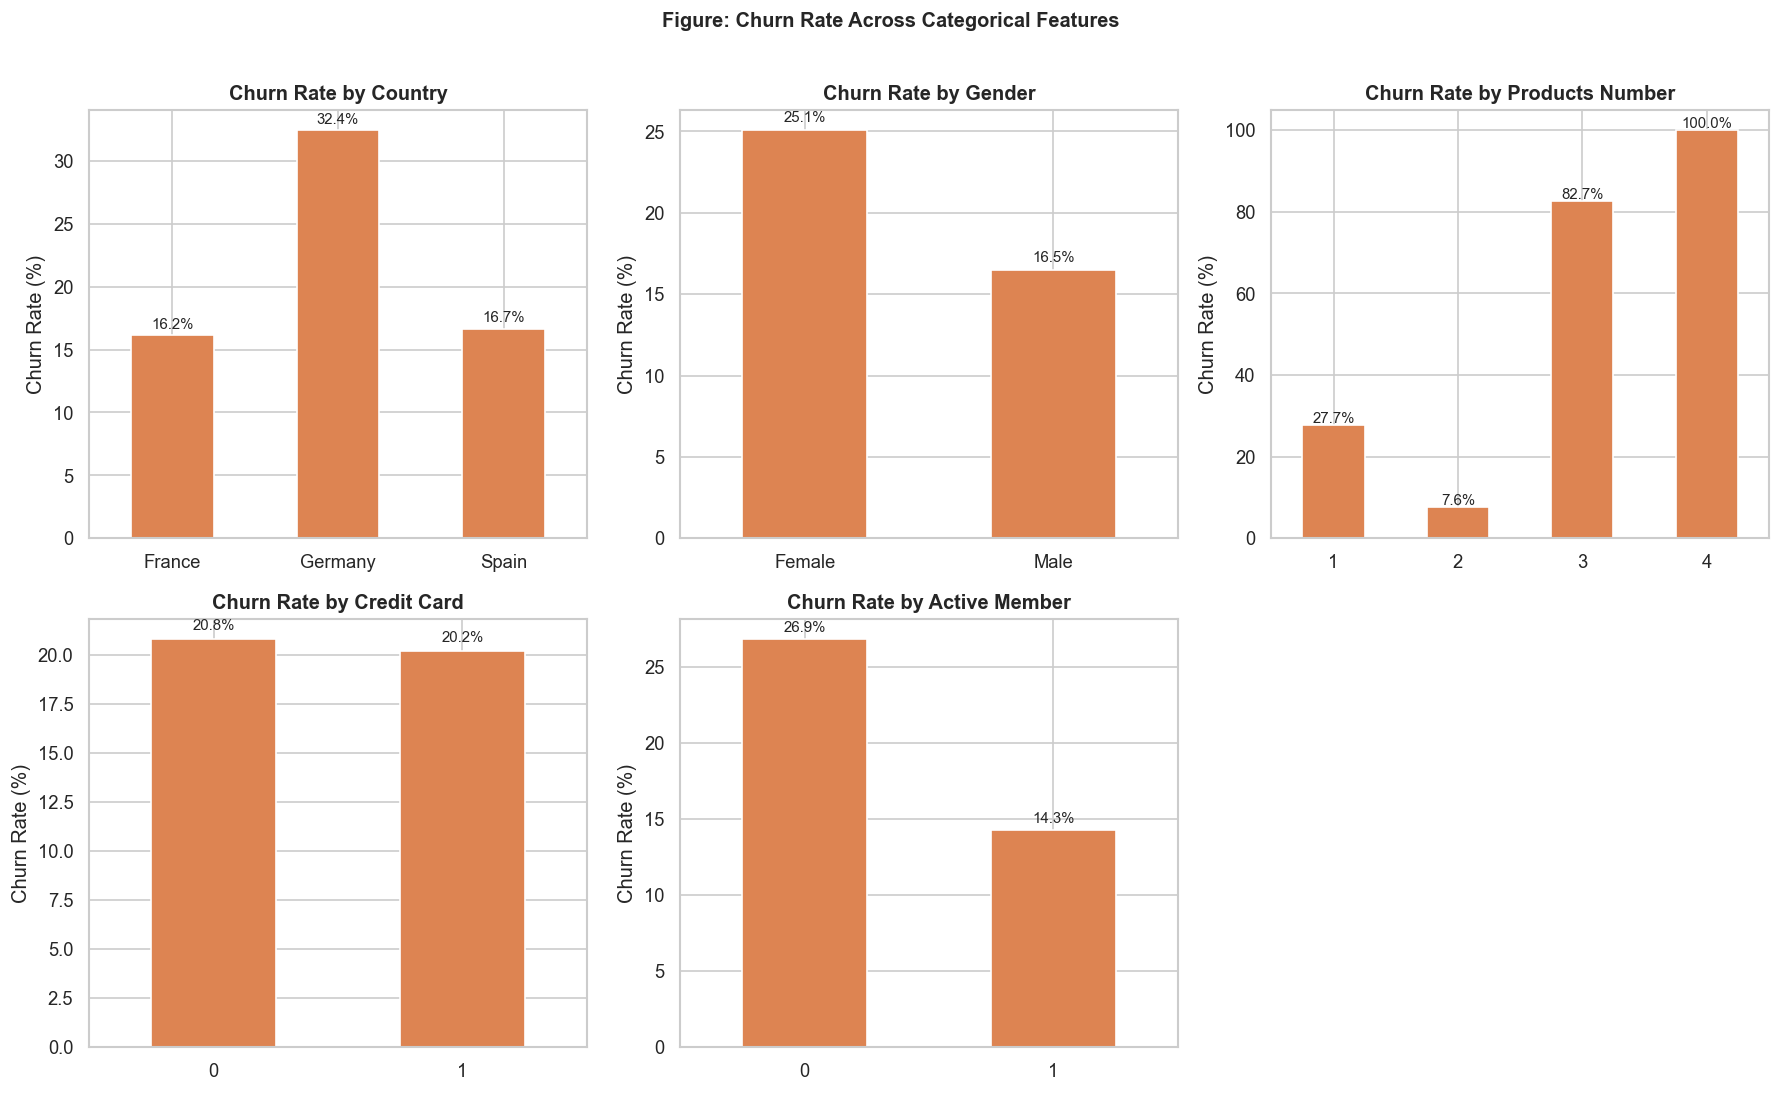

In [10]:
cat_features = ['country', 'gender', 'products_number', 'credit_card', 'active_member']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['churn'].mean() * 100
    churn_rate.plot(kind='bar', ax=axes[i], color='#DD8452', edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col.replace("_", " ").title()}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f'{bar.get_height():.1f}%', ha='center', fontsize=9)

axes[5].axis('off')
plt.suptitle('Figure: Churn Rate Across Categorical Features',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_categorical_churn_rates.png', bbox_inches='tight')
plt.show()

### 2.4 Correlation Heatmap

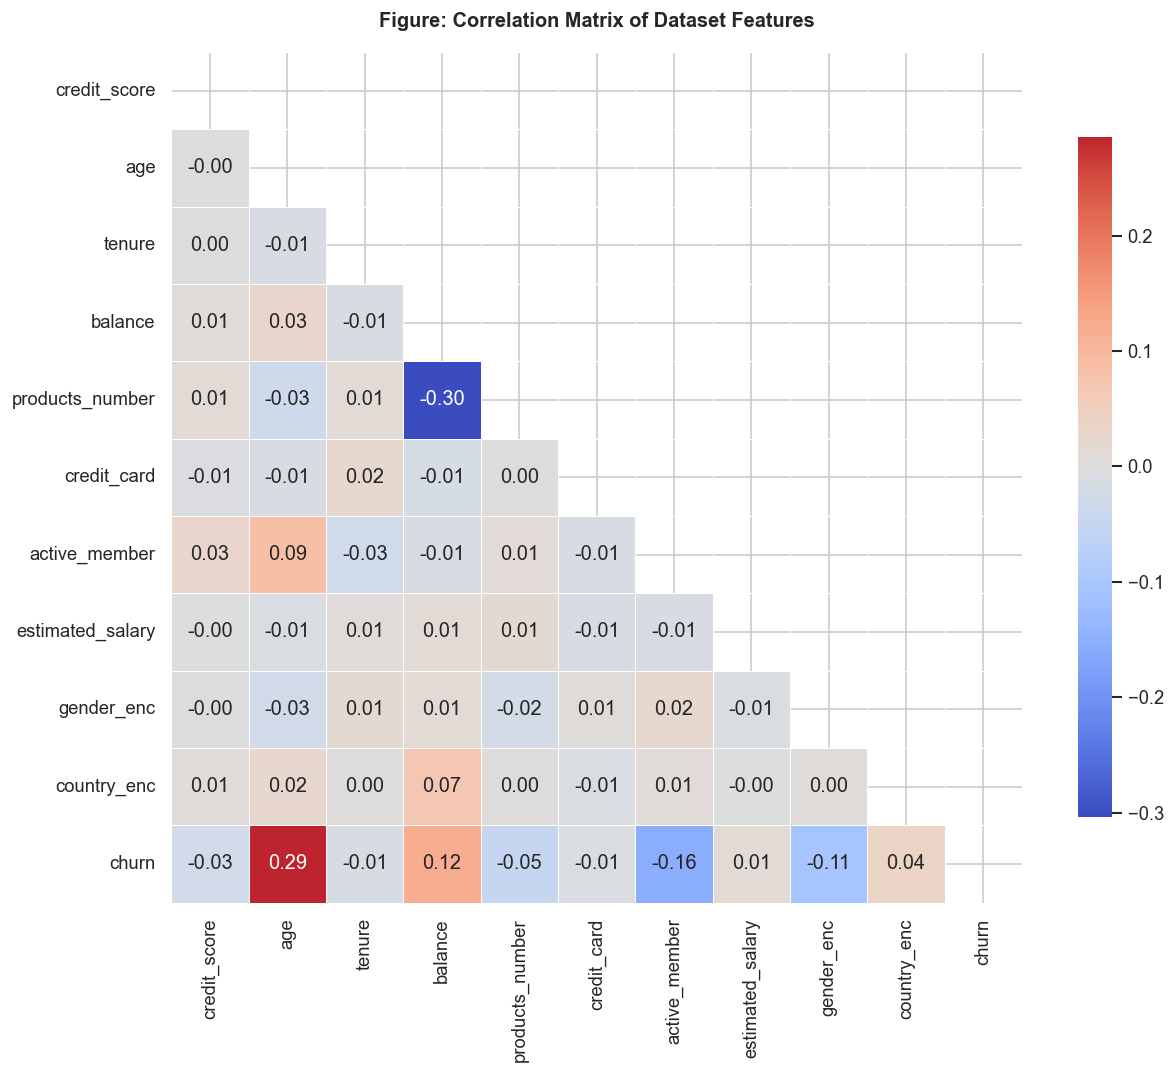

In [11]:
df_encoded = df.copy()
df_encoded['gender_enc'] = LabelEncoder().fit_transform(df_encoded['gender'])
df_encoded['country_enc'] = LabelEncoder().fit_transform(df_encoded['country'])
corr_cols = ['credit_score','age','tenure','balance','products_number',
             'credit_card','active_member','estimated_salary',
             'gender_enc','country_enc','churn']

corr_matrix = df_encoded[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Figure: Correlation Matrix of Dataset Features', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()

### 2.5 Outlier Detection via IQR

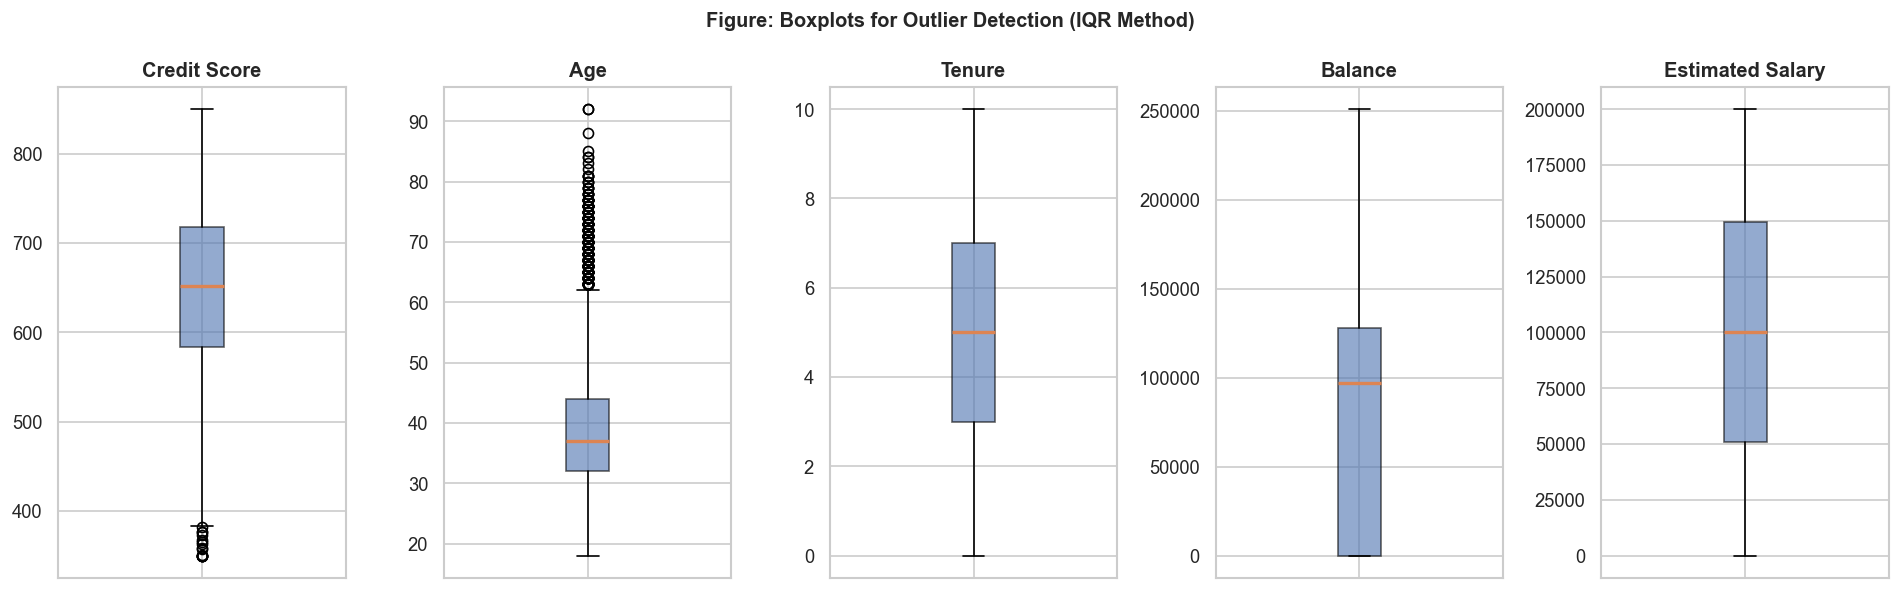

=== Outlier Counts (IQR method) ===
  credit_score        :   15 outliers (0.1%)
  age                 :  359 outliers (3.6%)
  tenure              :    0 outliers (0.0%)
  balance             :    0 outliers (0.0%)
  estimated_salary    :    0 outliers (0.0%)


In [12]:
fig, axes = plt.subplots(1, len(num_features), figsize=(16, 5))
for i, col in enumerate(num_features):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.6),
                    medianprops=dict(color='#DD8452', linewidth=2))
    axes[i].set_title(col.replace('_',' ').title(), fontweight='bold')
    axes[i].set_xticklabels([])

plt.suptitle('Figure: Boxplots for Outlier Detection (IQR Method)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_outlier_boxplots.png', bbox_inches='tight')
plt.show()

# Report outlier counts
print('=== Outlier Counts (IQR method) ===')
for col in num_features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f'  {col:20s}: {len(outliers):4d} outliers ({len(outliers)/len(df)*100:.1f}%)')

---
## 3. Data Preprocessing

### 3.1 Feature Removal

In [13]:
df_clean = df.drop(columns=['customer_id'])
print(f'Features after removal: {df_clean.shape[1]-1} predictors + 1 target')
print(df_clean.columns.tolist())

Features after removal: 10 predictors + 1 target
['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']


### 3.2 Encoding Categorical Variables

In [14]:
# Label encode Gender (binary)
le = LabelEncoder()
df_clean['gender'] = le.fit_transform(df_clean['gender'])   # Female=0, Male=1

# One-hot encode Country (3 categories)
df_clean = pd.get_dummies(df_clean, columns=['country'], drop_first=False)

print('Shape after encoding:', df_clean.shape)
print('Columns:', df_clean.columns.tolist())
df_clean.head(3)

Shape after encoding: (10000, 13)
Columns: ['credit_score', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn', 'country_France', 'country_Germany', 'country_Spain']


,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_France,country_Germany,country_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,True,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,True,False,False


### 3.3 Train-Test Split (80/20)

In [15]:
X = df_clean.drop('churn', axis=1)
y = df_clean['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set : {X_train.shape[0]:,} rows')
print(f'Test set     : {X_test.shape[0]:,} rows')
print(f'Train churn  : {y_train.mean()*100:.1f}%')
print(f'Test churn   : {y_test.mean()*100:.1f}%')

Training set : 8,000 rows
Test set     : 2,000 rows
Train churn  : 20.4%
Test churn   : 20.3%


### 3.4 Feature Scaling

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)         # apply same params to test

print('Scaling applied (mean=0, std=1).')
print(f'Feature means (train, first 4): {X_train_scaled.mean(axis=0)[:4].round(4)}')

Scaling applied (mean=0, std=1).
Feature means (train, first 4): [-0.  0.  0. -0.]


### 3.5 SMOTE — Class Balancing (Training Set Only)

Before SMOTE: {0: np.int64(6370), 1: np.int64(1630)}
After  SMOTE: {1: np.int64(6370), 0: np.int64(6370)}


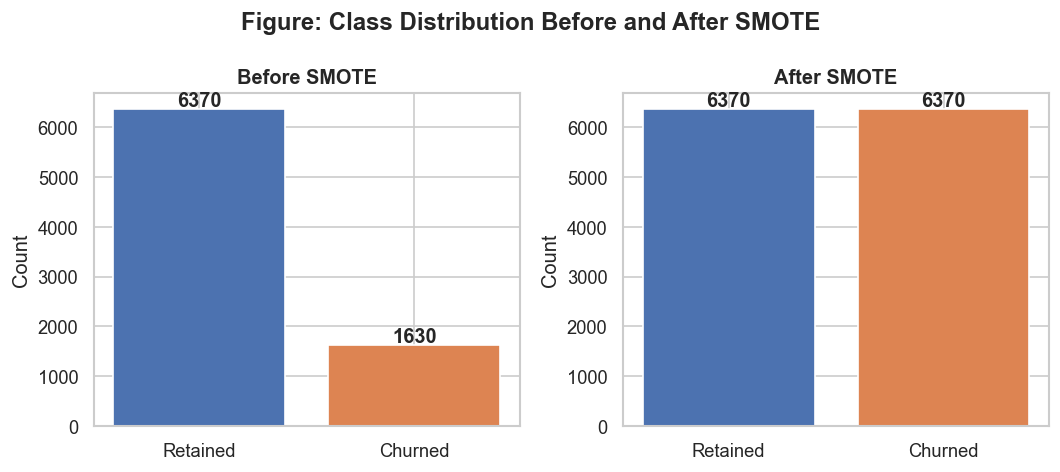

In [17]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:', dict(pd.Series(y_train).value_counts()))
print('After  SMOTE:', dict(pd.Series(y_train_res).value_counts()))

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, counts, title in zip(
    axes,
    [pd.Series(y_train).value_counts(), pd.Series(y_train_res).value_counts()],
    ['Before SMOTE', 'After SMOTE']
):
    ax.bar(['Retained', 'Churned'], [counts[0], counts[1]],
           color=['#4C72B0', '#DD8452'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v+50, str(v), ha='center', fontweight='bold')

plt.suptitle('Figure: Class Distribution Before and After SMOTE',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_smote_balance.png', bbox_inches='tight')
plt.show()

---
## 4. Model Training & Hyperparameter Tuning

In [18]:
# Helper: evaluate any fitted model
def evaluate_model(name, model, X_test, y_test, use_proba=True):
    y_pred = model.predict(X_test)
    if use_proba:
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
        from sklearn.preprocessing import minmax_scale
        y_prob = minmax_scale(y_prob)

    results = {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1-Score' : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 4),
    }
    return results, y_pred, y_prob

results_list = []
roc_data     = {}   # store (fpr, tpr) per model for combined ROC plot
trained_models = {}
print('Helper functions ready.')

Helper functions ready.


### 4.1 Logistic Regression

In [19]:
param_grid_lr = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gs_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                     param_grid_lr, cv=cv, scoring='roc_auc', n_jobs=-1)
gs_lr.fit(X_train_res, y_train_res)
best_lr = gs_lr.best_estimator_
print('Best params:', gs_lr.best_params_)

res, y_pred_lr, y_prob_lr = evaluate_model('Logistic Regression', best_lr, X_test_scaled, y_test)
results_list.append(res)
trained_models['Logistic Regression'] = (best_lr, y_prob_lr)
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_data['Logistic Regression'] = (fpr, tpr, res['ROC-AUC'])
print(res)

Best params: {'C': 10, 'solver': 'liblinear'}
{'Model': 'Logistic Regression', 'Accuracy': 0.717, 'Precision': 0.3906, 'Recall': 0.6978, 'F1-Score': 0.5009, 'ROC-AUC': 0.7768}


### 4.2 Decision Tree

In [20]:
param_grid_dt = {
    'max_depth': [3, 5, 8, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
gs_dt = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE),
                     param_grid_dt, cv=cv, scoring='roc_auc', n_jobs=-1)
gs_dt.fit(X_train_res, y_train_res)
best_dt = gs_dt.best_estimator_
print('Best params:', gs_dt.best_params_)

res, y_pred_dt, y_prob_dt = evaluate_model('Decision Tree', best_dt, X_test_scaled, y_test)
results_list.append(res)
trained_models['Decision Tree'] = (best_dt, y_prob_dt)
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
roc_data['Decision Tree'] = (fpr, tpr, res['ROC-AUC'])
print(res)

Best params: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_split': 10}
{'Model': 'Decision Tree', 'Accuracy': 0.8005, 'Precision': 0.5071, 'Recall': 0.6978, 'F1-Score': 0.5874, 'ROC-AUC': 0.8259}


### 4.3 Random Forest

In [21]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}
gs_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE),
                     param_grid_rf, cv=cv, scoring='roc_auc', n_jobs=-1)
gs_rf.fit(X_train_res, y_train_res)
best_rf = gs_rf.best_estimator_
print('Best params:', gs_rf.best_params_)

res, y_pred_rf, y_prob_rf = evaluate_model('Random Forest', best_rf, X_test_scaled, y_test)
results_list.append(res)
trained_models['Random Forest'] = (best_rf, y_prob_rf)
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_data['Random Forest'] = (fpr, tpr, res['ROC-AUC'])
print(res)

Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
{'Model': 'Random Forest', 'Accuracy': 0.842, 'Precision': 0.6135, 'Recall': 0.6044, 'F1-Score': 0.6089, 'ROC-AUC': 0.8472}


### 4.4 Support Vector Machine

In [22]:
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}
gs_svm = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    param_grid_svm, cv=cv, scoring='roc_auc', n_jobs=-1
)
gs_svm.fit(X_train_res, y_train_res)
best_svm = gs_svm.best_estimator_
print('Best params:', gs_svm.best_params_)

res, y_pred_svm, y_prob_svm = evaluate_model('SVM', best_svm, X_test_scaled, y_test)
results_list.append(res)
trained_models['SVM'] = (best_svm, y_prob_svm)
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)
roc_data['SVM'] = (fpr, tpr, res['ROC-AUC'])
print(res)

Best params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
{'Model': 'SVM', 'Accuracy': 0.7855, 'Precision': 0.4806, 'Recall': 0.6683, 'F1-Score': 0.5591, 'ROC-AUC': 0.809}


### 4.5 Gradient Boosting

In [23]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}
gs_gb = GridSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE),
                     param_grid_gb, cv=cv, scoring='roc_auc', n_jobs=-1)
gs_gb.fit(X_train_res, y_train_res)
best_gb = gs_gb.best_estimator_
print('Best params:', gs_gb.best_params_)

res, y_pred_gb, y_prob_gb = evaluate_model('Gradient Boosting', best_gb, X_test_scaled, y_test)
results_list.append(res)
trained_models['Gradient Boosting'] = (best_gb, y_prob_gb)
fpr, tpr, _ = roc_curve(y_test, y_prob_gb)
roc_data['Gradient Boosting'] = (fpr, tpr, res['ROC-AUC'])
print(res)

Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
{'Model': 'Gradient Boosting', 'Accuracy': 0.8515, 'Precision': 0.659, 'Recall': 0.5602, 'F1-Score': 0.6056, 'ROC-AUC': 0.8603}


### 4.6 Artificial Neural Network (ANN)

In [24]:
n_features = X_train_res.shape[1]

def build_ann(neurons=64, dropout=0.3, lr=0.001):
    model = Sequential([
        Dense(neurons, activation='relu', input_shape=(n_features,)),
        BatchNormalization(),
        Dropout(dropout),
        Dense(neurons // 2, activation='relu'),
        BatchNormalization(),
        Dropout(dropout),
        Dense(32, activation='relu'),
        Dropout(dropout / 2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

ann = build_ann(neurons=128, dropout=0.3, lr=0.001)
ann.summary()

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = ann.fit(
    X_train_res, y_train_res,
    validation_split=0.15,
    epochs=100,
    batch_size=64,
    callbacks=[es],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.6838 - loss: 0.6119 - val_accuracy: 0.6881 - val_loss: 0.6115
Epoch 2/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7436 - loss: 0.5263 - val_accuracy: 0.7321 - val_loss: 0.5523
Epoch 3/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7625 - loss: 0.4973 - val_accuracy: 0.7342 - val_loss: 0.5494
Epoch 4/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7716 - loss: 0.4792 - val_accuracy: 0.7452 - val_loss: 0.5354
Epoch 5/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7788 - loss: 0.4682 - val_accuracy: 0.7446 - val_loss: 0.5295
Epoch 6/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7818 - loss: 0.4634 - val_accuracy: 0.7363 - val_loss: 0.5284
Epoch 7/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7911 - loss: 0.4553 - val_accuracy: 0.7483 - val_loss: 0.5169
Epoch 8/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7842 - loss: 0.4504 -

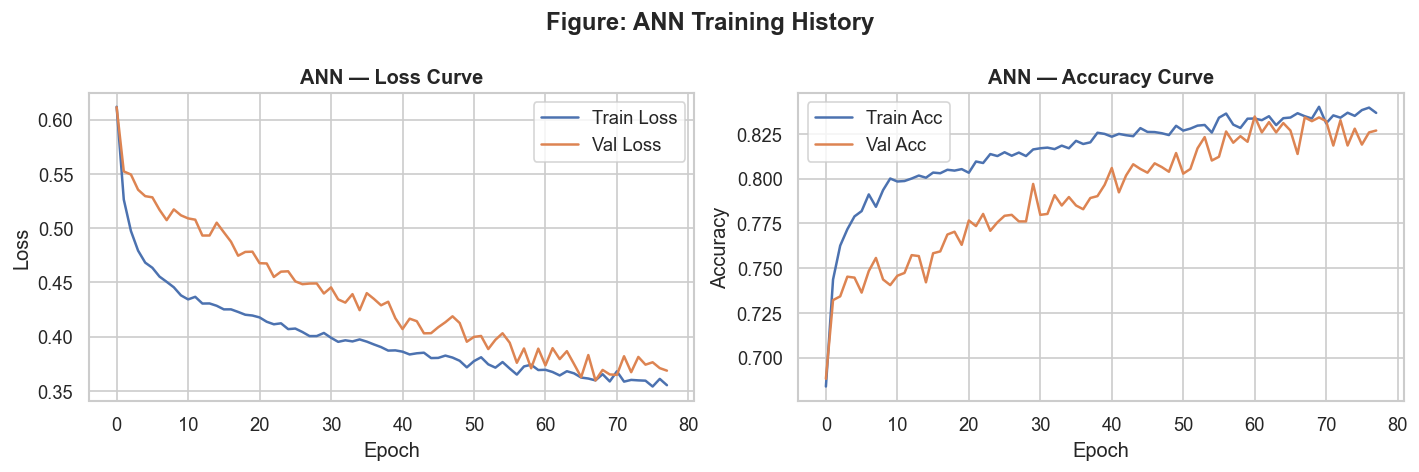

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
{'Model': 'ANN', 'Accuracy': 0.831, 'Precision': 0.5689, 'Recall': 0.7002, 'F1-Score': 0.6278, 'ROC-AUC': 0.8482}


In [25]:
# ANN training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss', color='#4C72B0')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#DD8452')
axes[0].set_title('ANN — Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Acc', color='#4C72B0')
axes[1].plot(history.history['val_accuracy'], label='Val Acc', color='#DD8452')
axes[1].set_title('ANN — Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.suptitle('Figure: ANN Training History', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ann_training.png', bbox_inches='tight')
plt.show()

# Evaluate ANN
y_prob_ann = ann.predict(X_test_scaled).flatten()
y_pred_ann = (y_prob_ann >= 0.5).astype(int)

res_ann = {
    'Model'    : 'ANN',
    'Accuracy' : round(accuracy_score(y_test, y_pred_ann), 4),
    'Precision': round(precision_score(y_test, y_pred_ann), 4),
    'Recall'   : round(recall_score(y_test, y_pred_ann), 4),
    'F1-Score' : round(f1_score(y_test, y_pred_ann), 4),
    'ROC-AUC'  : round(roc_auc_score(y_test, y_prob_ann), 4),
}
results_list.append(res_ann)
fpr, tpr, _ = roc_curve(y_test, y_prob_ann)
roc_data['ANN'] = (fpr, tpr, res_ann['ROC-AUC'])
print(res_ann)

---
## 5. Comparative Evaluation

### 5.1 Results Table

In [26]:
results_df = pd.DataFrame(results_list).sort_values('ROC-AUC', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index += 1   # rank from 1
print('=== Model Performance Summary (ranked by ROC-AUC) ===')
results_df

=== Model Performance Summary (ranked by ROC-AUC) ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Gradient Boosting,0.8515,0.6590,0.5602,0.6056,0.8603
2,ANN,0.8310,0.5689,0.7002,0.6278,0.8482
3,Random Forest,0.8420,0.6135,0.6044,0.6089,0.8472
4,Decision Tree,0.8005,0.5071,0.6978,0.5874,0.8259
5,SVM,0.7855,0.4806,0.6683,0.5591,0.8090
6,Logistic Regression,0.7170,0.3906,0.6978,0.5009,0.7768


### 5.2 Grouped Bar Chart — All Metrics

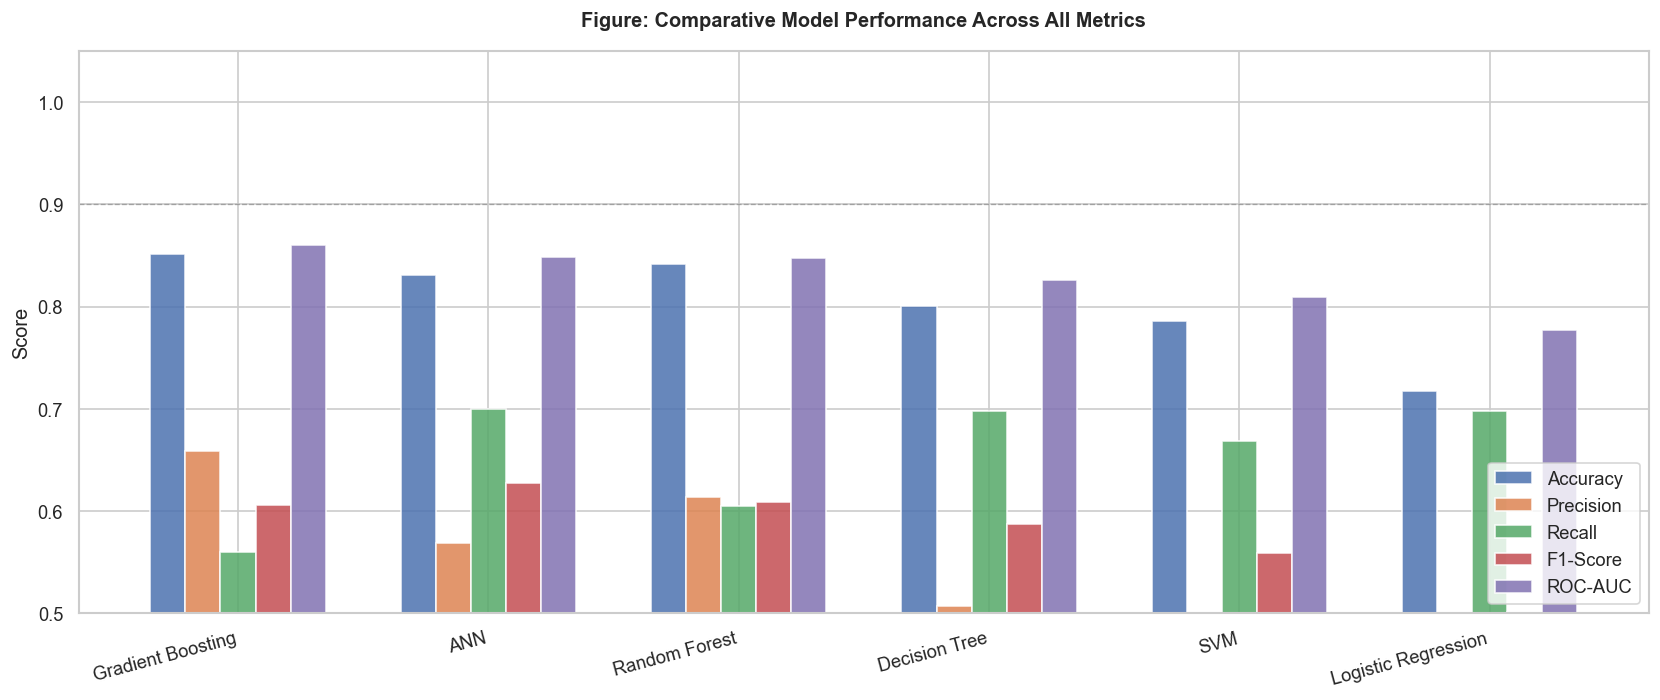

In [27]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models  = results_df['Model'].tolist()
x = np.arange(len(models))
width = 0.14
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = results_df[metric].tolist()
    bars = ax.bar(x + i*width, vals, width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width*2)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.05)
ax.set_title('Figure: Comparative Model Performance Across All Metrics',
             fontweight='bold', pad=15)
ax.legend(loc='lower right')
ax.axhline(0.9, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.savefig('fig_model_comparison.png', bbox_inches='tight')
plt.show()

### 5.3 Combined ROC Curves

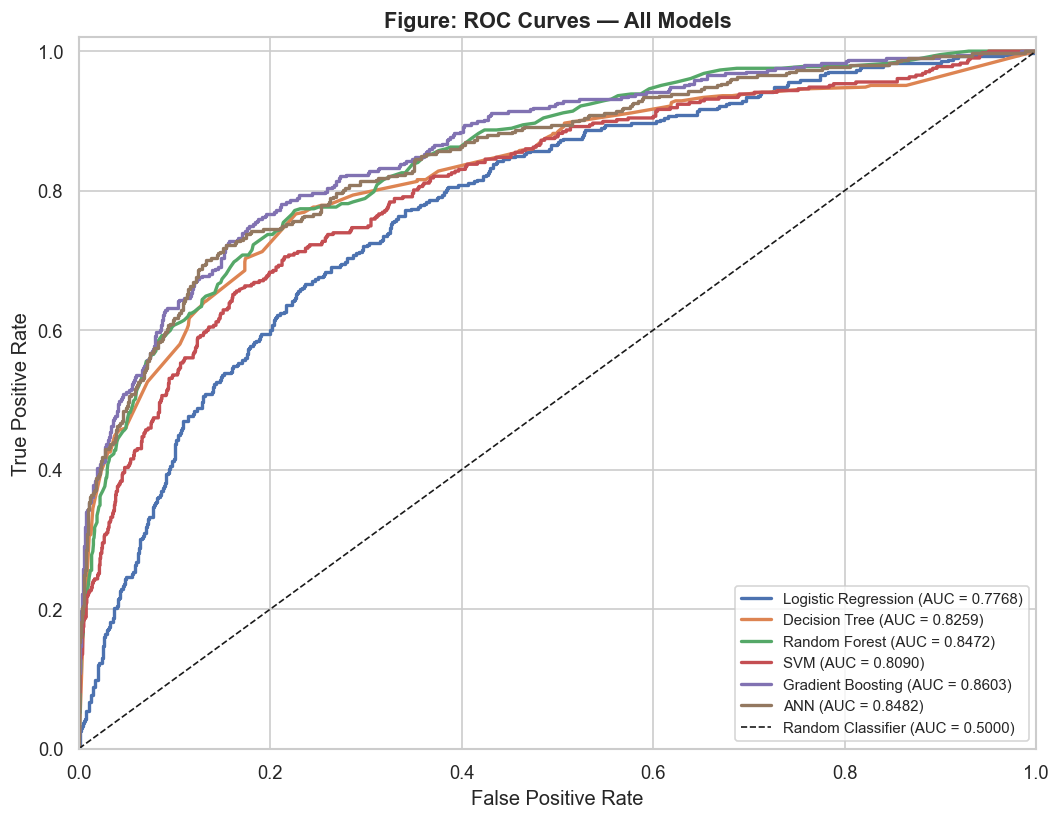

In [28]:
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

for (name, (fpr, tpr, auc_val)), color in zip(roc_data.items(), colors_roc):
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc_val:.4f})')

ax.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier (AUC = 0.5000)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Figure: ROC Curves — All Models', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig('fig_roc_curves.png', bbox_inches='tight')
plt.show()

### 5.4 Confusion Matrices

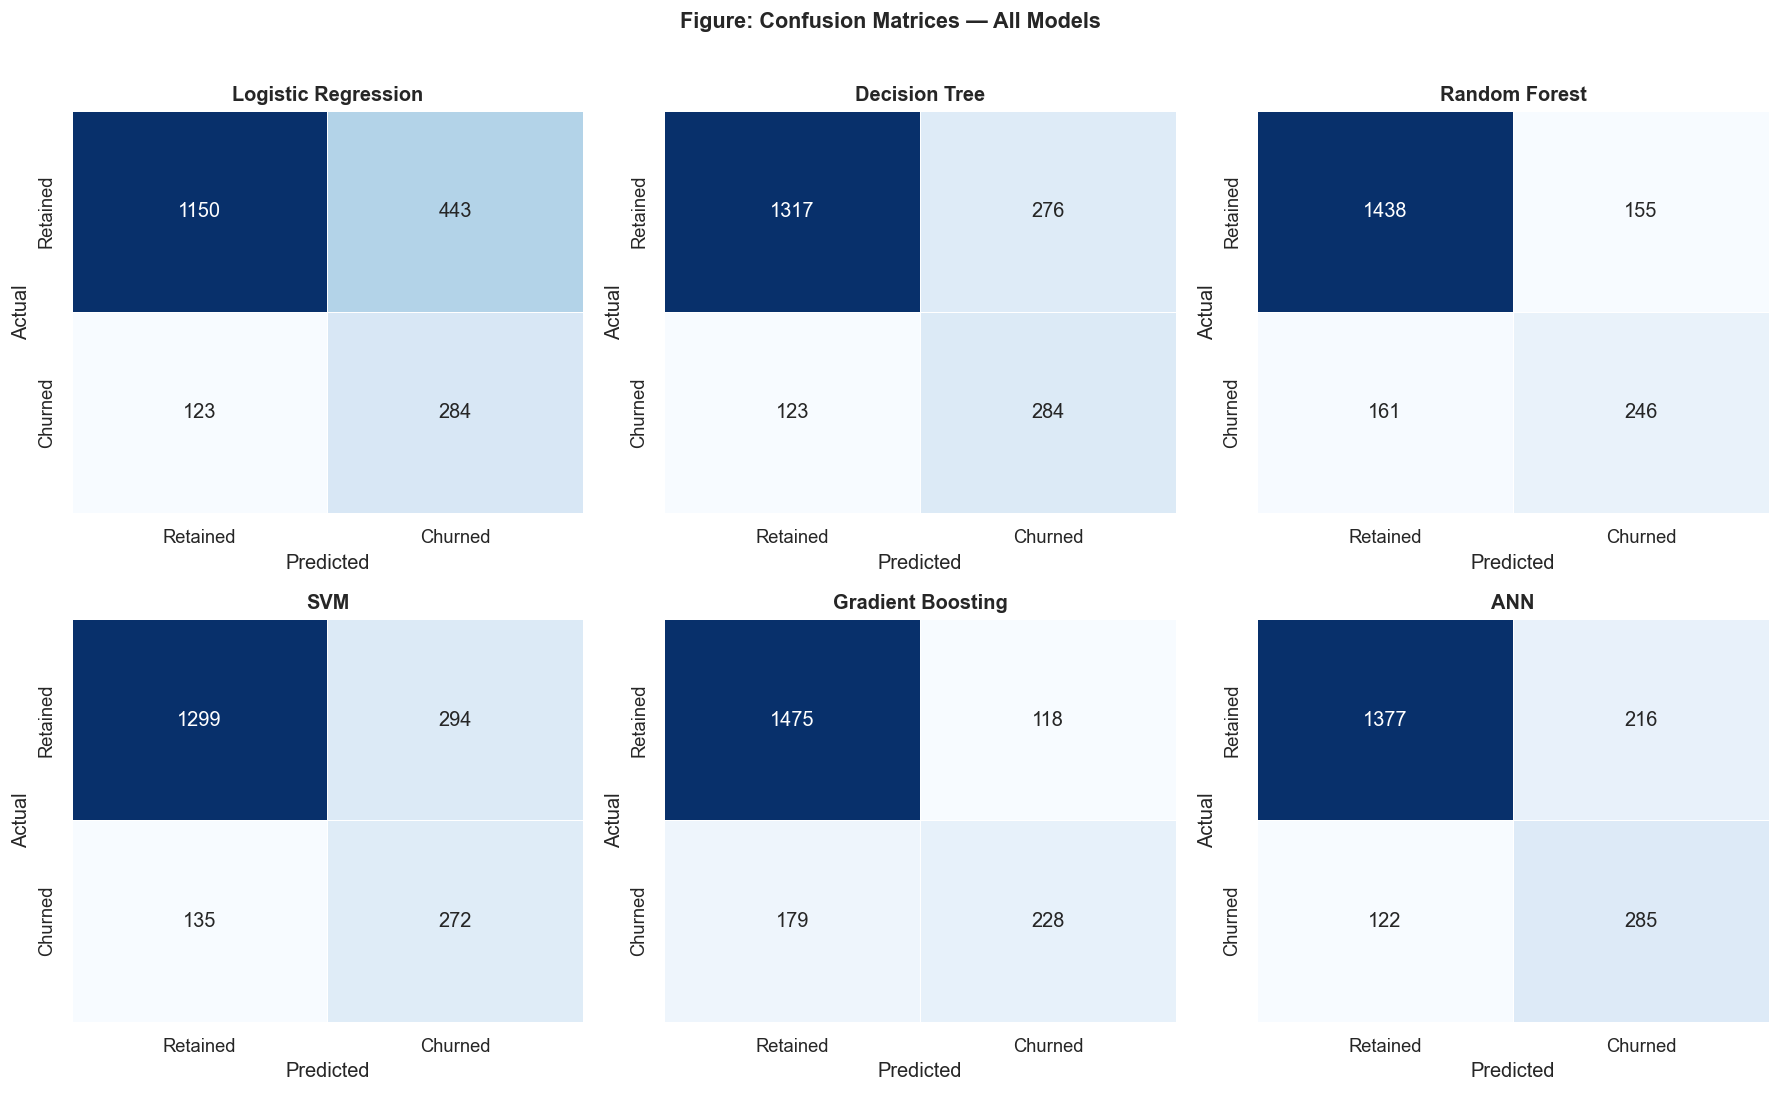

In [29]:
all_preds = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree'      : y_pred_dt,
    'Random Forest'      : y_pred_rf,
    'SVM'                : y_pred_svm,
    'Gradient Boosting'  : y_pred_gb,
    'ANN'                : y_pred_ann,
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(all_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Retained','Churned'],
                yticklabels=['Retained','Churned'],
                linewidths=0.5, cbar=False)
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Figure: Confusion Matrices — All Models', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', bbox_inches='tight')
plt.show()

### 5.5 Classification Reports

In [30]:
for name, y_pred in all_preds.items():
    print(f'\n{'='*50}')
    print(f'  {name}')
    print(f'{'='*50}')
    print(classification_report(y_test, y_pred,
                                target_names=['Retained', 'Churned']))


  Logistic Regression
              precision    recall  f1-score   support

    Retained       0.90      0.72      0.80      1593
     Churned       0.39      0.70      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000


  Decision Tree
              precision    recall  f1-score   support

    Retained       0.91      0.83      0.87      1593
     Churned       0.51      0.70      0.59       407

    accuracy                           0.80      2000
   macro avg       0.71      0.76      0.73      2000
weighted avg       0.83      0.80      0.81      2000


  Random Forest
              precision    recall  f1-score   support

    Retained       0.90      0.90      0.90      1593
     Churned       0.61      0.60      0.61       407

    accuracy                           0.84      2000
   macro avg       0.76      0.75      0.75      2000
weighted avg     

---
## 6. SHAP Explainability Analysis

### 6.1 SHAP — Best Tree Model (Gradient Boosting)

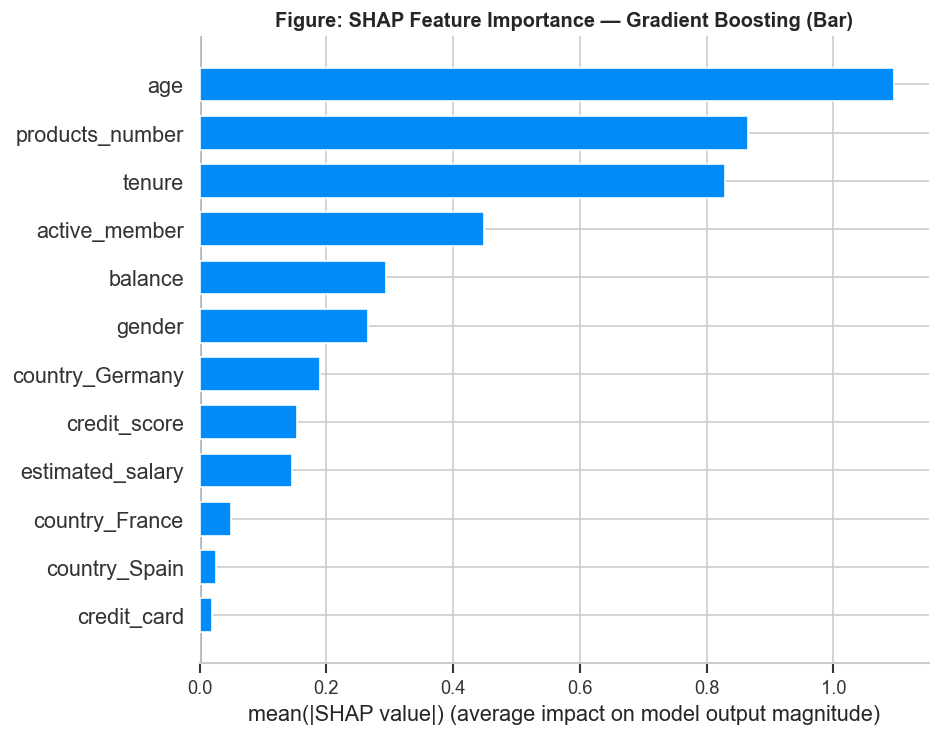

In [31]:
# Use original feature names for readability
feature_names = X.columns.tolist()
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

explainer_gb = shap.TreeExplainer(best_gb)
shap_values_gb = explainer_gb.shap_values(X_test_df)

# Global feature importance — Summary Plot (Bar)
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values_gb, X_test_df, plot_type='bar',
                  show=False)
plt.title('Figure: SHAP Feature Importance — Gradient Boosting (Bar)',
          fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_bar_gb.png', bbox_inches='tight')
plt.show()

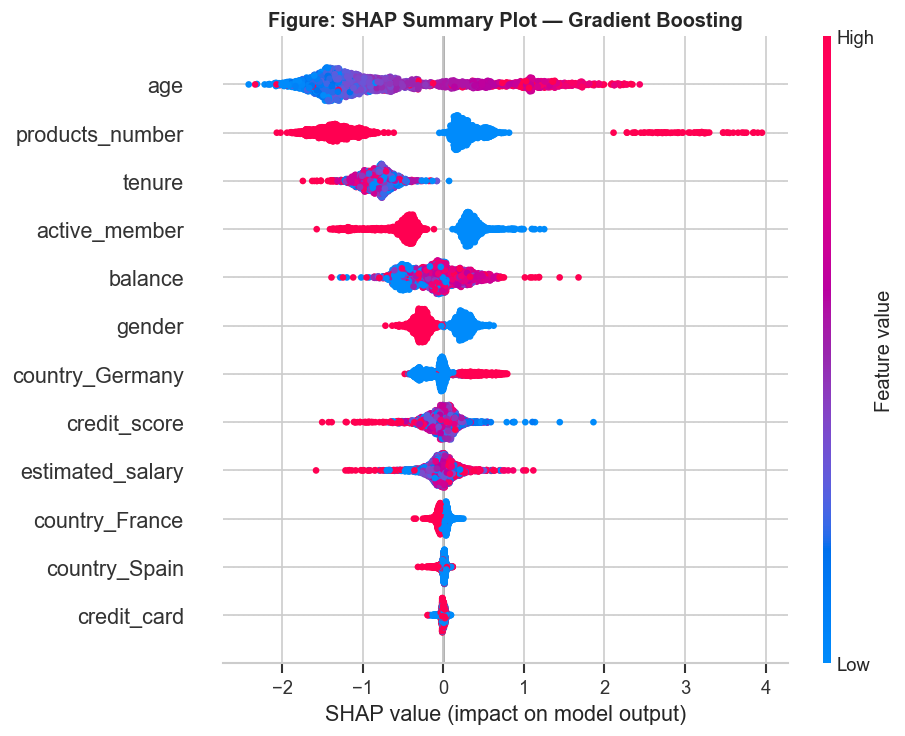

In [32]:
# SHAP Beeswarm / Dot Plot
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values_gb, X_test_df, show=False)
plt.title('Figure: SHAP Summary Plot — Gradient Boosting',
          fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_beeswarm_gb.png', bbox_inches='tight')
plt.show()

### 6.2 SHAP — Random Forest

<Figure size 1080x720 with 0 Axes>

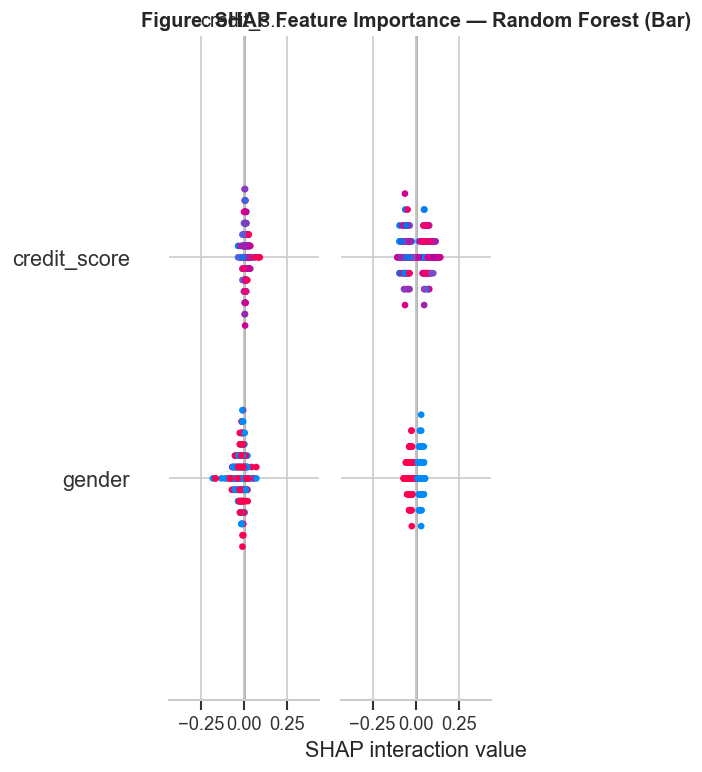

In [33]:
X_sample = pd.DataFrame(X_test_df[:200], columns = X.columns.tolist())
explainer_rf = shap.TreeExplainer(best_rf)
shap_values_rf = explainer_rf.shap_values(X_sample)

# For RF, shap_values is a list [class0, class1] — take class 1
sv_rf = shap_values_rf[1] if isinstance(shap_values_rf, list) else shap_values_rf

plt.figure(figsize=(9, 6))
shap.summary_plot(sv_rf, X_sample, plot_type='bar', show=False)
plt.title('Figure: SHAP Feature Importance — Random Forest (Bar)',
          fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_bar_rf.png', bbox_inches='tight')
plt.show()

### 6.3 SHAP Force Plot — Single Prediction Example

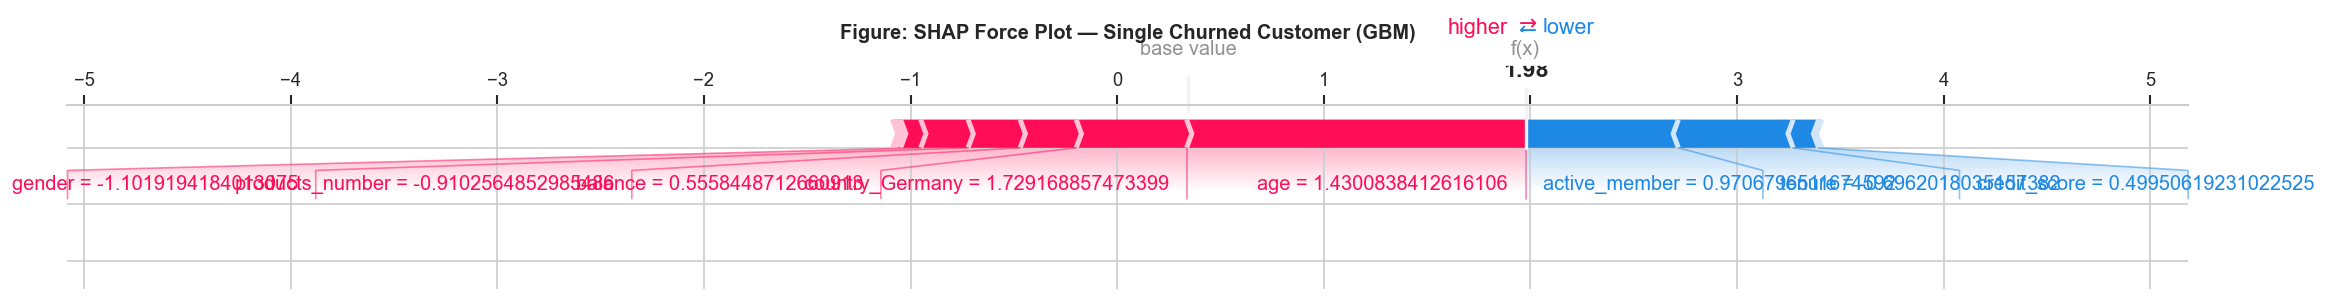

In [34]:
# Pick first churned customer from test set for illustration
churned_idx = np.where(y_test.values == 1)[0][0]

shap.initjs()
force_plot = shap.force_plot(
    explainer_gb.expected_value,
    shap_values_gb[churned_idx],
    X_test_df.iloc[churned_idx],
    matplotlib=True,
    show=False
)
plt.title('Figure: SHAP Force Plot — Single Churned Customer (GBM)',
          fontweight='bold', pad=40)
plt.tight_layout()
plt.savefig('fig_shap_force_plot.png', bbox_inches='tight')
plt.show()

---
## 7. Final Comparison & Recommendation

In [35]:
print('\n' + '='*65)
print('   FINAL MODEL PERFORMANCE SUMMARY (Ranked by ROC-AUC)')
print('='*65)
print(results_df.to_string())
print('='*65)

best_model = results_df.iloc[0]
print(f'\n🏆 Best model by ROC-AUC : {best_model["Model"]}')
print(f'   ROC-AUC  : {best_model["ROC-AUC"]}')
print(f'   Recall   : {best_model["Recall"]}')
print(f'   F1-Score : {best_model["F1-Score"]}')


   FINAL MODEL PERFORMANCE SUMMARY (Ranked by ROC-AUC)
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
1    Gradient Boosting    0.8515     0.6590  0.5602    0.6056   0.8603
2                  ANN    0.8310     0.5689  0.7002    0.6278   0.8482
3        Random Forest    0.8420     0.6135  0.6044    0.6089   0.8472
4        Decision Tree    0.8005     0.5071  0.6978    0.5874   0.8259
5                  SVM    0.7855     0.4806  0.6683    0.5591   0.8090
6  Logistic Regression    0.7170     0.3906  0.6978    0.5009   0.7768

🏆 Best model by ROC-AUC : Gradient Boosting
   ROC-AUC  : 0.8603
   Recall   : 0.5602
   F1-Score : 0.6056


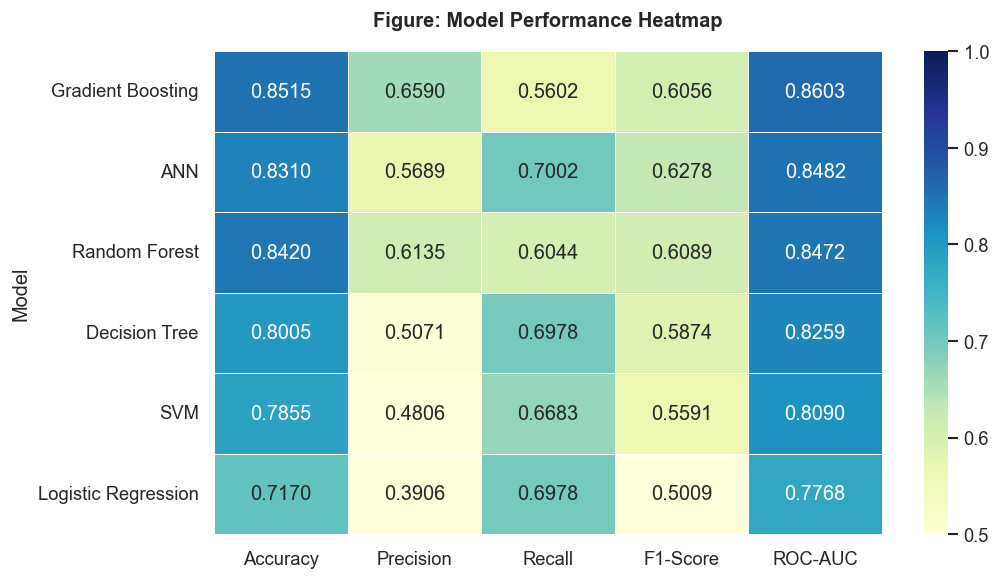

In [36]:
# Heatmap of all metrics per model
heat_df = results_df.set_index('Model')[metrics]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(heat_df, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, ax=ax, vmin=0.5, vmax=1.0)
ax.set_title('Figure: Model Performance Heatmap', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_performance_heatmap.png', bbox_inches='tight')
plt.show()

---
*End of Implementation — Odegbami, Oluwagbemiro Olamide (210805525)*